In [1]:
import numpy as np
import scipy.constants
import scipy.sparse
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import math
import geopandas as gpd
import pandas as pd
import os
import netCDF4 as nc

In [2]:
def calc_alongshore_transport_k(gravity=scipy.constants.g, n=1.0, rho_water=1050.0, gamma_b=0.78, ):

    '''Calculates sediment transport constant k.'''
    
    return (
        5.3e-6
        # * 0.46
        * rho_water
        * gravity**1.5
        * (1 / (2 * n)) ** 1.2
        * (np.sqrt(gravity * gamma_b) / (2 * np.pi)) ** 0.2
    )

In [3]:
def get_angles_xr(ds):
    
    ''' Takes average latitude and longitude calculated in beahc_w_to_gps.ipynb and computes bearing using bearing formula
    \(\theta =\>\mathrm{atan2}\>(\sin \Delta \lambda \cdot \cos \phi _{2},\cos \phi _{1}\cdot \sin \phi _{2}-\sin \phi _{1}\cdot \cos \phi _{2}\cdot \cos \Delta \lambda )\).'''
    
    lat = np.radians(ds['mean_lat'])
    lon = np.radians(ds['mean_lon'])

    lat1 = lat.shift(site=1)
    lon1 = lon.shift(site=1)
    lat2 = lat.shift(site=-1)
    lon2 = lon.shift(site=-1)

    dlon = lon2 - lon1
    
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)

    bearing = np.degrees(np.arctan2(y, x))
    bearing = (bearing + 360) % 360
    bearing_clean = bearing.fillna(0)

    return ds.assign(bearing=bearing_clean)

In [4]:
def calc_qs_mu(dp, hs, tp, angles, k, d=8): # mean direction of propagation bearing from north (degrees), significant wave height (meters), period (seconds), k, shoreface depth (meters) 

    '''Calculates Q_s and diffusivity (mu) using formula from Ashton, Murray 2006 B, equation (7) and (8). Negative sign is added so that positive Q_s 
    corresponds to rightward sediment movement when facing offshore (in this case, roughly south-bound).'''
    
    tp_da = tp['tp'] if isinstance(tp, xr.Dataset) else tp # just in case
    hs_da = hs['hs'] if isinstance(hs, xr.Dataset) else hs
    dp_da = dp['dp'] if isinstance(dp, xr.Dataset) else dp

    phi = dp_da - 90
    thet = ((angles + 90) % 360) - 90 # assumes no shoreline bearing angles equal to 270
    angle_term = ((phi - thet + 180) % 360) - 180
    angle_term = angle_term.where(np.abs(angle_term) <= 90) # mask areas where waves appear to be moving away from shore
    angle_term_abs = np.abs(angle_term)
    rad_factor = np.pi / 180
    angle_term = angle_term * rad_factor
    angle_term_abs = angle_term_abs * rad_factor
    cos_term = np.cos(angle_term)
    sin_term = np.sin(angle_term)
    sin_term_abs = np.sin(angle_term_abs)
    cos_term_abs = np.cos(angle_term_abs)
    power_term = ((tp_da * cos_term) ** 0.2) * (hs_da ** 2.4) 
    power_term_abs = ((tp_da * cos_term_abs) ** 0.2) * (hs_da ** 2.4)
    coeff = k / d
    mu = -(coeff * power_term_abs * ((1.2 * (sin_term_abs**2)) - (cos_term_abs**2)))
    qs = -k * (tp_da ** .2) * (hs_da ** 2.4) * (cos_term ** 1.2) * sin_term # CERC formula, negative fixes the bearing assumption so that downdrift qs is positive
    # qs = -k * (hs_da ** 2) * cos_term * sin_term # breaking wave formula
    return qs, mu, angle_term

In [5]:
def get_u_a(ds, start_date, end_date):

    '''Calculates U, the fraction of high angle wave contribution to Q_s over the total wave contribution to Q_s over the given time period.
    High-angle threshold is defined by the absolute angle between wave crests and the shoreline being greater than pi/4.'''

    '''Calculates A, the fraction of high rightward wave contribution to Q_s over the total wave contribution to Q_s over the given time period.'''
    
    ds_subset = ds.sel(time=slice(start_date, end_date))
    
    high_mask = (ds_subset['angle_diff'] > (np.pi/4)) | (ds_subset['angle_diff'] < -(np.pi/4))
    low_mask  = (ds_subset['angle_diff'] <= (np.pi/4)) & (ds_subset['angle_diff'] >= -(np.pi/4))
    qs_high = np.abs(ds_subset['qs'].where(high_mask)).sum(dim='time')
    qs_low  = np.abs(ds_subset['qs'].where(low_mask)).sum(dim='time')
    total1 = qs_low + qs_high
    u = (qs_high / total1)

    left_mask = (ds_subset['angle_diff'] < 0)
    right_mask = (ds_subset['angle_diff'] >= 0)
    qs_left = np.abs(ds_subset['qs'].where(left_mask)).sum(dim='time')
    qs_right  = np.abs(ds_subset['qs'].where(right_mask)).sum(dim='time')
    total2 = qs_left + qs_right
    a = (qs_left / total2)
    
    return u, a

In [6]:
dp = xr.open_dataset('dp_merged_all.nc') # peak direction
hs = xr.open_dataset('hs_merged_all.nc') # wave height
tp = xr.open_dataset('tp_merged_all.nc') # peak period
shore = xr.open_dataset('NC_average_lat_lon.nc') # shoreline points

In [7]:
# compute shoreline angles (bearing from north)
angles_xr = get_angles_xr(shore)

In [8]:
# iterate through wave sample ids, time periods, and latitude boundaries and calculate sediment transport statistics
id_list = [2844, 3096, 3142]

time_list = [
    ['1984-01-01T12:00:00', '2004-01-01T12:00:00'],
    ['2004-01-01T12:00:00', '2024-01-01T12:00:00']
]

lat_bounds = [
    [35.237, 36.642]
]

# compute mean shoreline angle between two latitude bounds
bearing_list = []

for i in range(len(lat_bounds)):
    angles = angles_xr.where((angles_xr['mean_lat'] >= lat_bounds[i][0]) & (angles_xr['mean_lat'] <= lat_bounds[i][1]), drop=True) 
    
    rad = np.radians(angles['bearing'])

    mean_sin = np.sin(rad).mean(dim='site')
    mean_cos = np.cos(rad).mean(dim='site')

    mean_angle_rad = np.arctan2(mean_sin, mean_cos)
    mean_bearing = np.degrees(mean_angle_rad)
    mean_bearing = (mean_bearing + 360) % 360

    bearing_list.append(mean_bearing.values)

k = calc_alongshore_transport_k()

results = []

# calculate statistics
for i in range(len(id_list)):
    site_id = id_list[i]
    
    dp_site = dp.sel(site=site_id)
    hs_site = hs.sel(site=site_id)
    tp_site = tp.sel(site=site_id)
    
    for j in range(len(bearing_list)):
        bearing_val = bearing_list[j]

        qs_da, mu_da, angle_term_da = calc_qs_mu(
            dp=dp_site, hs=hs_site, tp=tp_site, angles=bearing_val, k=k
        )
        
        site_wave_ds = xr.Dataset({
            'qs': qs_da,
            'angle_diff': angle_term_da, 
            'mu': mu_da
        })

        lat_window = lat_bounds[j]
        
        for m in range(len(time_list)):
            start = time_list[m][0]
            end = time_list[m][1]

            u_val, a_val = get_u_a(site_wave_ds, start_date=start, end_date=end)

            time_subset = site_wave_ds.sel(time=slice(start, end))

            mu_avg = time_subset['mu'].mean(dim='time')
            qs_sum = time_subset['qs'].sum(dim='time')

            results.append({
                'site': site_id,
                'lat_bounds': lat_window,
                'time_window': f"{start} to {end}",
                'bearing': bearing_val,
                'mu_avg': float(mu_avg.values),
                'qs_sum': float(qs_sum.values),
                'u': float(u_val.values),
                'a': float(a_val.values)
            })

df_results = pd.DataFrame(results)
print(df_results)            

   site        lat_bounds                                 time_window  \
0  2844  [35.237, 36.642]  1984-01-01T12:00:00 to 2004-01-01T12:00:00   
1  2844  [35.237, 36.642]  2004-01-01T12:00:00 to 2024-01-01T12:00:00   
2  3096  [35.237, 36.642]  1984-01-01T12:00:00 to 2004-01-01T12:00:00   
3  3096  [35.237, 36.642]  2004-01-01T12:00:00 to 2024-01-01T12:00:00   
4  3142  [35.237, 36.642]  1984-01-01T12:00:00 to 2004-01-01T12:00:00   
5  3142  [35.237, 36.642]  2004-01-01T12:00:00 to 2024-01-01T12:00:00   

              bearing    mu_avg       qs_sum         u         a  
0  348.32407775843853 -0.000200  6651.077148  0.455431  0.736683  
1  348.32407775843853  0.002097  7176.770996  0.444971  0.739102  
2  348.32407775843853  0.001867  6997.814453  0.447642  0.736374  
3  348.32407775843853  0.004049  7826.160645  0.433944  0.746694  
4  348.32407775843853  0.004504  3945.253906  0.421048  0.639709  
5  348.32407775843853  0.005376  4676.594727  0.422716  0.653259  


In [9]:
# iterate through wave sample ids, time periods, and latitude boundaries and calculate sediment transport statistics
id_list = [2844, 3096, 3142]

time_list = [
    ['1992-01-01T12:00:00', '2007-01-01T12:00:00'],
    ['2008-01-01T12:00:00', '2024-01-01T12:00:00']
]

lat_bounds = [
    [35.231204, 35.774414]
]

# compute mean shoreline angle between two latitude bounds
bearing_list = []

for i in range(len(lat_bounds)):
    angles = angles_xr.where((angles_xr['mean_lat'] >= lat_bounds[i][0]) & (angles_xr['mean_lat'] <= lat_bounds[i][1]), drop=True) 
    
    rad = np.radians(angles['bearing'])

    mean_sin = np.sin(rad).mean(dim='site')
    mean_cos = np.cos(rad).mean(dim='site')

    mean_angle_rad = np.arctan2(mean_sin, mean_cos)
    mean_bearing = np.degrees(mean_angle_rad)
    mean_bearing = (mean_bearing + 360) % 360

    bearing_list.append(mean_bearing.values)

k = calc_alongshore_transport_k()

results = []

# calculate statistics
for i in range(len(id_list)):
    site_id = id_list[i]
    
    dp_site = dp.sel(site=site_id)
    hs_site = hs.sel(site=site_id)
    tp_site = tp.sel(site=site_id)
    
    for j in range(len(bearing_list)):
        bearing_val = bearing_list[j]

        qs_da, mu_da, angle_term_da = calc_qs_mu(
            dp=dp_site, hs=hs_site, tp=tp_site, angles=bearing_val, k=k
        )
        
        site_wave_ds = xr.Dataset({
            'qs': qs_da,
            'angle_diff': angle_term_da, 
            'mu': mu_da
        })

        lat_window = lat_bounds[j]
        
        for m in range(len(time_list)):
            start = time_list[m][0]
            end = time_list[m][1]

            u_val, a_val = get_u_a(site_wave_ds, start_date=start, end_date=end)

            time_subset = site_wave_ds.sel(time=slice(start, end))

            mu_avg = time_subset['mu'].mean(dim='time')
            qs_sum = time_subset['qs'].sum(dim='time')

            results.append({
                'site': site_id,
                'lat_bounds': lat_window,
                'time_window': f"{start} to {end}",
                'bearing': bearing_val,
                'mu_avg': float(mu_avg.values),
                'qs_sum': float(qs_sum.values),
                'u': float(u_val.values),
                'a': float(a_val.values)
            })

df_results = pd.DataFrame(results)
print(df_results)            

   site              lat_bounds                                 time_window  \
0  2844  [35.231204, 35.774414]  1992-01-01T12:00:00 to 2007-01-01T12:00:00   
1  2844  [35.231204, 35.774414]  2008-01-01T12:00:00 to 2024-01-01T12:00:00   
2  3096  [35.231204, 35.774414]  1992-01-01T12:00:00 to 2007-01-01T12:00:00   
3  3096  [35.231204, 35.774414]  2008-01-01T12:00:00 to 2024-01-01T12:00:00   
4  3142  [35.231204, 35.774414]  1992-01-01T12:00:00 to 2007-01-01T12:00:00   
5  3142  [35.231204, 35.774414]  2008-01-01T12:00:00 to 2024-01-01T12:00:00   

             bearing    mu_avg       qs_sum         u         a  
0  4.774102075972678 -0.007095  4500.614746  0.462131  0.689162  
1  4.774102075972678 -0.007132  4837.582031  0.471966  0.681926  
2  4.774102075972678 -0.006186  5248.870605  0.454671  0.708885  
3  4.774102075972678 -0.006920  5729.078125  0.463174  0.703914  
4  4.774102075972678 -0.001715  3337.818848  0.430248  0.626926  
5  4.774102075972678 -0.003004  3792.326172  0.447

In [10]:
def get_endpoint_bearing(ds, lat_min, lat_max, lat_var='mean_lat', lon_var='mean_lon'):

    """Bearing of the straight chord connecting the two endpoints of a shoreline domain.

    Unlike the circular mean of per-site bearings, this describes the net orientation of the
    reach and is insensitive to local curvature and GPS noise. Endpoints are chosen as the
    southernmost and northernmost sites within the latitude window, and the bearing is always
    reported south -> north so the seaward normal (bearing + 90) points roughly east. Reversing
    that order would shift the bearing by 180 deg, which leaves mu unchanged but inverts the
    onshore/offshore mask and flips the sign of Q_s.

    Returns the chord bearing (deg from north) and a diagnostics dict, including sinuosity:
    the summed point-to-point path length divided by the chord length. Values near 1 mean the
    reach is nearly straight and a single bearing is representative; larger values mean real
    curvature is being collapsed into one number.
    """

    sub = ds.where((ds[lat_var] >= lat_min) & (ds[lat_var] <= lat_max), drop=True)

    lat_vals = np.asarray(sub[lat_var].values, dtype=float)
    lon_vals = np.asarray(sub[lon_var].values, dtype=float)

    good = np.isfinite(lat_vals) & np.isfinite(lon_vals)
    if good.sum() < 2:
        raise ValueError(f'need >= 2 valid shoreline points in [{lat_min}, {lat_max}]')
    lat_vals, lon_vals = lat_vals[good], lon_vals[good]

    order = np.argsort(lat_vals)          # pin direction: south -> north
    i0, i1 = order[0], order[-1]

    lat1, lon1 = np.radians(lat_vals[i0]), np.radians(lon_vals[i0])
    lat2, lon2 = np.radians(lat_vals[i1]), np.radians(lon_vals[i1])
    dlon = lon2 - lon1

    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(y, x)) % 360

    # haversine chord length, and path length along sites in latitude order
    R = 6371000.0
    def _hav(p1, l1, p2, l2):
        a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin((l2 - l1) / 2) ** 2
        return 2 * R * np.arcsin(np.sqrt(a))

    chord = _hav(lat1, lon1, lat2, lon2)
    plat, plon = np.radians(lat_vals[order]), np.radians(lon_vals[order])
    path = _hav(plat[:-1], plon[:-1], plat[1:], plon[1:]).sum()

    # circular mean of per-site bearings, for comparison
    mean_bearing = np.nan
    if 'bearing' in sub:
        b = np.radians(np.asarray(sub['bearing'].values, dtype=float))
        b = b[np.isfinite(b)]
        if b.size:
            mean_bearing = np.degrees(np.arctan2(np.sin(b).sum(), np.cos(b).sum())) % 360

    info = {
        'n_sites': int(lat_vals.size),
        'lat_start': float(lat_vals[i0]), 'lon_start': float(lon_vals[i0]),
        'lat_end':   float(lat_vals[i1]), 'lon_end':   float(lon_vals[i1]),
        'chord_km': chord / 1000.0,
        'path_km': path / 1000.0,
        'sinuosity': path / chord if chord > 0 else np.nan,
        'seaward_normal': (bearing + 90) % 360,
        'circular_mean_bearing': mean_bearing,
        'bearing_minus_mean': ((bearing - mean_bearing + 180) % 360) - 180,
    }
    return float(bearing), info

In [11]:
def calc_stats_for_bearing(dp, hs, tp, site_ids, bearing_val, time_windows, k, d=8):

    """Runs calc_qs_mu at a single shoreline bearing and summarises each site/time window.

    Reports mu_avg alongside the fraction of records that are antidiffusive and the ratio of
    negative to positive mu contributions, because mu_avg is a small residual of two large
    opposing terms and its sign alone is easy to over-read. n_valid counts unmasked records so
    an empty window is distinguishable from a genuine zero.
    """

    rows = []
    for site_id in site_ids:
        qs_da, mu_da, angle_da = calc_qs_mu(
            dp=dp.sel(site=site_id), hs=hs.sel(site=site_id), tp=tp.sel(site=site_id),
            angles=bearing_val, k=k, d=d,
        )
        ds_site = xr.Dataset({'qs': qs_da, 'angle_diff': angle_da, 'mu': mu_da})

        for start, end in time_windows:
            sub = ds_site.sel(time=slice(start, end))
            mu, qs = sub['mu'], sub['qs']
            n_valid = int(mu.count())

            u_val, a_val = get_u_a(ds_site, start_date=start, end_date=end)

            mu_neg = float(mu.where(mu < 0).sum())
            mu_pos = float(mu.where(mu > 0).sum())

            rows.append({
                'site': site_id,
                'time_window': f'{start} to {end}',
                'bearing': bearing_val,
                'n_valid': n_valid,
                'frac_masked': 1 - n_valid / int(mu.sizes['time']) if mu.sizes['time'] else np.nan,
                # min_count=1 so an all-NaN window stays NaN instead of collapsing to 0.0
                'mu_avg': float(mu.mean()) if n_valid else np.nan,
                'mu_frac_neg': float((mu < 0).sum() / n_valid) if n_valid else np.nan,
                'mu_neg_over_pos': abs(mu_neg / mu_pos) if mu_pos else np.nan,
                'qs_sum': float(qs.sum(min_count=1)),
                'u': float(u_val),
                'a': float(a_val),
            })
    return pd.DataFrame(rows)

In [12]:
# Statistics using the bearing between the ENDPOINTS of each domain
id_list = [2844, 3096, 3142]

time_list = [
    ['1992-01-01T12:00:00', '2007-01-01T12:00:00'],
    ['2008-01-01T12:00:00', '2024-01-01T12:00:00'],
]

lat_bounds = [
    [35.231204, 35.774414],   
    [35.237, 36.642],         
]

k_coeff = calc_alongshore_transport_k()

all_results = []
for lat_min, lat_max in lat_bounds:
    bearing_val, info = get_endpoint_bearing(angles_xr, lat_min, lat_max)

    print(f'[{lat_min}, {lat_max}]  n={info["n_sites"]}')
    print(f'  endpoints      : ({info["lat_start"]:.4f}, {info["lon_start"]:.4f}) '
          f'-> ({info["lat_end"]:.4f}, {info["lon_end"]:.4f})')
    print(f'  chord bearing  : {bearing_val:.2f} deg   seaward normal {info["seaward_normal"]:.2f} deg')
    print(f'  circular mean  : {info["circular_mean_bearing"]:.2f} deg '
          f'(chord - mean = {info["bearing_minus_mean"]:+.2f} deg)')
    print(f'  chord {info["chord_km"]:.1f} km / path {info["path_km"]:.1f} km  '
          f'-> sinuosity {info["sinuosity"]:.3f}\n')

    df = calc_stats_for_bearing(dp, hs, tp, id_list, bearing_val, time_list, k_coeff)
    df.insert(1, 'lat_bounds', str([lat_min, lat_max]))
    all_results.append(df)

df_endpoint = pd.concat(all_results, ignore_index=True)
pd.set_option('display.width', 200, 'display.max_columns', 50)
print(df_endpoint.to_string(index=False))

[35.231204, 35.774414]  n=1330
  endpoints      : (35.2312, -75.6104) -> (35.7731, -75.5245)
  chord bearing  : 7.33 deg   seaward normal 97.33 deg
  circular mean  : 4.77 deg (chord - mean = +2.55 deg)
  chord 60.8 km / path 289.8 km  -> sinuosity 4.769

[35.237, 36.642]  n=2971
  endpoints      : (35.2371, -75.5262) -> (36.5504, -75.8674)
  chord bearing  : 348.21 deg   seaward normal 78.21 deg
  circular mean  : 348.32 deg (chord - mean = -0.11 deg)
  chord 149.2 km / path 155.8 km  -> sinuosity 1.044

 site             lat_bounds                                time_window    bearing  n_valid  frac_masked    mu_avg  mu_frac_neg  mu_neg_over_pos      qs_sum        u        a
 2844 [35.231204, 35.774414] 1992-01-01T12:00:00 to 2007-01-01T12:00:00   7.325484    91529     0.303946 -0.008267     0.610495         1.802630 4252.732910 0.478853 0.676890
 2844 [35.231204, 35.774414] 2008-01-01T12:00:00 to 2024-01-01T12:00:00   7.325484    98895     0.294836 -0.008348     0.618363         1.7

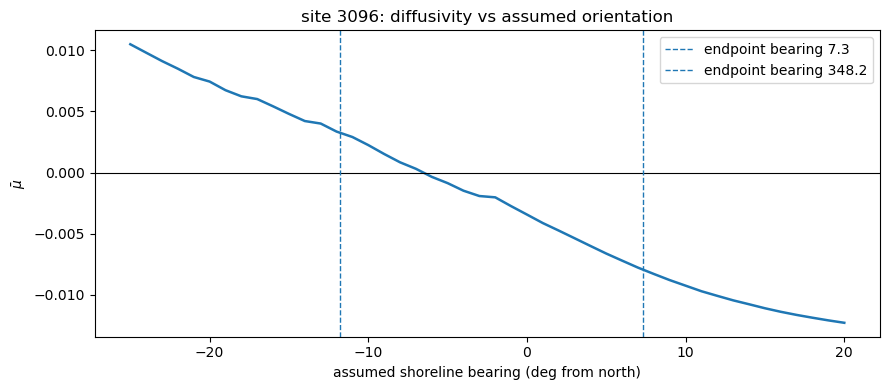

zero crossings near bearings: [354.0]


In [14]:
# How sensitive is the sign of mu to the assumed shoreline bearing?
# mu_avg is a small residual, so scan the plausible orientation range and find the zero crossing.
site_id = 3096
start, end = '1992-01-01T12:00:00', '2024-01-01T12:00:00'
k_coeff = calc_alongshore_transport_k()

bearing_grid = np.arange(-25.0, 20.5, 1.0)        # -25 .. +20, i.e. 335 .. 020
sweep = []
for b_unwrapped in bearing_grid:
    b = float(b_unwrapped % 360)
    df_b = calc_stats_for_bearing(dp, hs, tp, [site_id], b, [[start, end]], k_coeff)
    sweep.append({
        'bearing': b,
        'bearing_unwrapped': float(b_unwrapped),
        'mu_avg': df_b['mu_avg'].iloc[0],
        'u': df_b['u'].iloc[0],
    })

df_sweep = pd.DataFrame(sweep).sort_values('bearing_unwrapped')
df_sweep['bearing_unwrapped'] = np.where(df_sweep['bearing'] > 180,
                                         df_sweep['bearing'] - 360, df_sweep['bearing'])
df_sweep = df_sweep.sort_values('bearing_unwrapped')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_sweep['bearing_unwrapped'], df_sweep['mu_avg'], lw=1.8)
ax.axhline(0, color='k', lw=0.8)
for lat_min, lat_max in lat_bounds:
    bv, _ = get_endpoint_bearing(angles_xr, lat_min, lat_max)
    ax.axvline(bv - 360 if bv > 180 else bv, ls='--', lw=1,
               label=f'endpoint bearing {bv:.1f}')
ax.set_xlabel('assumed shoreline bearing (deg from north)')
ax.set_ylabel(r'$\bar{\mu}$')
ax.set_title(f'site {site_id}: diffusivity vs assumed orientation')
ax.legend()
plt.tight_layout()
plt.show()

sign_change = df_sweep['mu_avg'].apply(np.sign).diff().ne(0) & df_sweep['mu_avg'].notna()
print('zero crossings near bearings:',
      df_sweep.loc[sign_change.fillna(False), 'bearing'].round(1).tolist()[1:])